
### What this phase does
Phase 2 predicted **how many minutes** a train would be late (regression).  
Phase 3 predicts **which delay class** a train falls into (multiclass classification):

| Class | Label | Delay range |
|-------|-------|-------------|
| 0 | On time / early | ≤ 0 min |
| 1 | Slight delay | 1 – 5 min |
| 2 | Moderate delay | 6 – 15 min |
| 3 | Severe delay | > 15 min |

These thresholds are operationally meaningful: **6 min** is Deutsche Bahn's official "delayed" threshold, and **15 min** triggers passenger compensation rights.

### Models trained (5 total)
0. **Majority Class Baseline** — always predicts the most frequent class
1. **Logistic Regression** — multiclass (OvR vs Softmax, best selected)
2. **XGBoost Classifier** — gradient boosting with SHAP interpretability
3. **LightGBM Classifier** — fast boosting, class-weight aware
4. **MLP Neural Network** — multi-layer perceptron with softmax output

### Prerequisites
Run **Phase 1** (v4, ride-based split) first — produces `outputs/db_train.parquet`, `outputs/db_test.parquet`, `outputs/config.json`  
Run **Phase 2** (v4, corrected) first — produces `outputs/phase2_predictions.parquet`, `outputs/phase2_config.json`

In [1]:
# ════════════════════════════════════════════════════════════
# CELL 1 · IMPORTS
# ════════════════════════════════════════════════════════════

import warnings, json, time, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

warnings.filterwarnings("ignore")
np.random.seed(42)

# ── Scikit-learn ──────────────────────────────────────────────
from sklearn.linear_model        import LogisticRegression
from sklearn.preprocessing       import StandardScaler, label_binarize
from sklearn.pipeline            import Pipeline
from sklearn.metrics             import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, ConfusionMatrixDisplay,
    log_loss
)
from sklearn.calibration         import calibration_curve
from sklearn.utils.class_weight  import compute_class_weight

# ── Gradient boosting ─────────────────────────────────────────
from xgboost  import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier

# ── SHAP (for XGBoost interpretability) ───────────────────────
try:
    import shap
    SHAP_AVAILABLE = True
    print("✅  shap available")
except ImportError:
    SHAP_AVAILABLE = False
    print("⚠️  shap not installed — run: pip install shap --quiet")

# ── Deep learning ─────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks as K_CB
tf.random.set_seed(42)

# ── Paths ─────────────────────────────────────────────────────
OUTPUT_DIR = Path("outputs")
FIG_DIR    = OUTPUT_DIR / "figures"
MODEL_DIR  = OUTPUT_DIR / "models"
FIG_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

# ── Plot style — matches Phase 1 & 2 ─────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
PAL     = sns.color_palette("muted", 10)
FIG_DPI = 150
CLASS_COLORS = [PAL[2], PAL[0], PAL[1], PAL[3]]

print("✅  Phase 3 imports ready.")


✅  shap available
✅  Phase 3 imports ready.


In [2]:
# ════════════════════════════════════════════════════════════
# CELL 2 · LOAD PHASE 1 & 2 OUTPUTS
# ════════════════════════════════════════════════════════════

df_train = pd.read_parquet(OUTPUT_DIR / "db_train.parquet")
df_test  = pd.read_parquet(OUTPUT_DIR / "db_test.parquet")

with open(OUTPUT_DIR / "config.json") as f:
    cfg = json.load(f)

with open(OUTPUT_DIR / "phase2_config.json") as f:
    p2_cfg = json.load(f)

FEATURES_TREE       = cfg["FEATURES_TREE"]
FEATURES_LINEAR     = cfg["FEATURES_LINEAR"]
WEATHER_FEATURES    = cfg["WEATHER_FEATURES"]
LAG_FEATURES        = cfg["LAG_FEATURES"]
CONGESTION_FEATURES = cfg["CONGESTION_FEATURES"]
TARGET_REG          = cfg["TARGET_REG"]     # "delay_in_min"
TARGET_CLF          = "delay_class"         # 0-3 multiclass target
LEAKAGE_COLS        = cfg["LEAKAGE_COLS"]

CLASS_LABELS = {
    0: "On time/early",
    1: "Slight (1-5m)",
    2: "Moderate (6-15m)",
    3: "Severe (>15m)",
}
N_CLASSES = 4

# ── Sanity checks ──────────────────────────────────────────────
split_strategy = cfg.get("split_strategy", "unknown")
print(f"Split strategy   : {split_strategy}")
assert "ride_based" in split_strategy, (
    "Please re-run Phase 1 (v4) — ride-based split required."
)

train_rides = set(df_train["train_line_ride_id"].unique())
test_rides  = set(df_test["train_line_ride_id"].unique())
overlap     = train_rides & test_rides
print(f"Ride overlap     : {len(overlap)} rides in both -> ", end="")
print("✅ CLEAN" if len(overlap) == 0 else f"❌ PROBLEM: {len(overlap)} leaked!")

assert TARGET_CLF in df_train.columns, (
    f"Column '{TARGET_CLF}' missing — check Phase 1 output."
)

print(f"\nTrain rows : {len(df_train):,}")
print(f"Test rows  : {len(df_test):,}")
print(f"\nClass distribution (train):")
vc_train = df_train[TARGET_CLF].value_counts().sort_index()
for k, v in vc_train.items():
    bar = "█" * int(v / len(df_train) * 40)
    print(f"  [{k}] {CLASS_LABELS[k]:20s}: {v:>9,}  ({v/len(df_train)*100:5.1f}%)  {bar}")

print(f"\nClass distribution (test):")
vc_test = df_test[TARGET_CLF].value_counts().sort_index()
for k, v in vc_test.items():
    bar = "█" * int(v / len(df_test) * 40)
    print(f"  [{k}] {CLASS_LABELS[k]:20s}: {v:>9,}  ({v/len(df_test)*100:5.1f}%)  {bar}")

print(f"\nPhase 2 best model : {p2_cfg['best_model_name']}")
print(f"Phase 2 MAE        : {p2_cfg['best_mae']:.3f} min  (regression)")
print(f"Phase 3 will now classify delay_in_min into 4 categories.")


Split strategy   : ride_based_GroupShuffleSplit
Ride overlap     : 0 rides in both -> ✅ CLEAN

Train rows : 715,232
Test rows  : 178,310

Class distribution (train):
  [0] On time/early       :   313,969  ( 43.9%)  █████████████████
  [1] Slight (1-5m)       :   310,784  ( 43.5%)  █████████████████
  [2] Moderate (6-15m)    :    65,732  (  9.2%)  ███
  [3] Severe (>15m)       :    24,747  (  3.5%)  █

Class distribution (test):
  [0] On time/early       :    78,975  ( 44.3%)  █████████████████
  [1] Slight (1-5m)       :    77,474  ( 43.4%)  █████████████████
  [2] Moderate (6-15m)    :    15,636  (  8.8%)  ███
  [3] Severe (>15m)       :     6,225  (  3.5%)  █

Phase 2 best model : MLP Neural Network
Phase 2 MAE        : 0.913 min  (regression)
Phase 3 will now classify delay_in_min into 4 categories.


In [3]:
# ════════════════════════════════════════════════════════════
# CELL 3 · FEATURE MATRICES & CLASS WEIGHTS
# ════════════════════════════════════════════════════════════

# Keep only features that actually exist in both splits
FEATURES_TREE   = [f for f in FEATURES_TREE   if f in df_train.columns]
FEATURES_LINEAR = [f for f in FEATURES_LINEAR if f in df_train.columns]

# Hard leakage guard:
# - delay_in_min is the regression target; binning it gives delay_class directly
# - delay_class IS the classification target
# - is_delayed and is_severe are derived from delay_in_min
EXTRA_LEAKAGE = LEAKAGE_COLS + [TARGET_CLF, TARGET_REG, "is_delayed", "is_severe"]
for bad in EXTRA_LEAKAGE:
    assert bad not in FEATURES_TREE,   f"Leakage: {bad} in FEATURES_TREE"
    assert bad not in FEATURES_LINEAR, f"Leakage: {bad} in FEATURES_LINEAR"
print("Leakage check : ✅ passed — no target leakage in feature lists")

X_tr_tree   = df_train[FEATURES_TREE].fillna(0).values.astype("float32")
X_te_tree   = df_test[FEATURES_TREE].fillna(0).values.astype("float32")
X_tr_linear = df_train[FEATURES_LINEAR].fillna(0).values.astype("float32")
X_te_linear = df_test[FEATURES_LINEAR].fillna(0).values.astype("float32")

y_train = df_train[TARGET_CLF].values.astype("int32")
y_test  = df_test[TARGET_CLF].values.astype("int32")

# ── Early-stopping validation split (same approach as Phase 2) ──
# Use last 10% of training rows chronologically.
# This slice is NEVER shown to evaluate test-set performance.
n_val        = int(len(X_tr_tree) * 0.10)
X_val_tree   = X_tr_tree[-n_val:]
y_val        = y_train[-n_val:]
X_fit_tree   = X_tr_tree[:-n_val]
y_fit        = y_train[:-n_val]

# ── Class weights ─────────────────────────────────────────────
# Class imbalance is significant: class 0 (on time) is often
# the majority. Balanced weights ensure the model pays attention
# to Moderate and Severe delays, which are the actionable classes.
classes     = np.array([0, 1, 2, 3])
raw_weights = compute_class_weight("balanced", classes=classes, y=y_train)
CLASS_WEIGHT_DICT = {i: float(w) for i, w in enumerate(raw_weights)}

print(f"\nFeature matrices:")
print(f"  X_tr_tree   : {X_tr_tree.shape}")
print(f"  X_te_tree   : {X_te_tree.shape}")
print(f"  X_tr_linear : {X_tr_linear.shape}")
print(f"  X_te_linear : {X_te_linear.shape}")
print(f"\nEarly-stopping validation (from training only):")
print(f"  X_fit_tree  : {X_fit_tree.shape}  (90%)")
print(f"  X_val_tree  : {X_val_tree.shape}  (10%)")
print(f"\nClass weights (balanced):")
for k, w in CLASS_WEIGHT_DICT.items():
    print(f"  Class {k} ({CLASS_LABELS[k]:20s}): weight = {w:.4f}")


Leakage check : ✅ passed — no target leakage in feature lists

Feature matrices:
  X_tr_tree   : (715232, 60)
  X_te_tree   : (178310, 60)
  X_tr_linear : (715232, 57)
  X_te_linear : (178310, 57)

Early-stopping validation (from training only):
  X_fit_tree  : (643709, 60)  (90%)
  X_val_tree  : (71523, 60)  (10%)

Class weights (balanced):
  Class 0 (On time/early       ): weight = 0.5695
  Class 1 (Slight (1-5m)       ): weight = 0.5753
  Class 2 (Moderate (6-15m)    ): weight = 2.7203
  Class 3 (Severe (>15m)       ): weight = 7.2254


In [4]:
# ════════════════════════════════════════════════════════════
# CELL 4 · UNIFIED EVALUATION FUNCTION
# ════════════════════════════════════════════════════════════

all_results = []
all_preds   = {}
all_probas  = {}

def evaluate_clf(name, y_true, y_pred, y_proba, train_time_s):
    acc    = float(accuracy_score(y_true, y_pred))
    f1_mac = float(f1_score(y_true, y_pred, average="macro",    zero_division=0))
    f1_wt  = float(f1_score(y_true, y_pred, average="weighted", zero_division=0))
    ll     = float(log_loss(y_true, y_proba))

    per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)

    try:
        auc = float(roc_auc_score(
            label_binarize(y_true, classes=[0, 1, 2, 3]),
            y_proba, multi_class="ovr", average="macro"
        ))
    except Exception:
        auc = float("nan")

    # Binary: did we correctly detect "operationally delayed" (class >= 2)?
    delayed_true = (y_true >= 2).astype(int)
    delayed_pred = (y_pred >= 2).astype(int)
    delay_detect = float(accuracy_score(delayed_true, delayed_pred))

    row = {
        "Model"            : name,
        "Accuracy (%)"     : round(acc * 100, 2),
        "Macro F1"         : round(f1_mac, 4),
        "Weighted F1"      : round(f1_wt,  4),
        "ROC-AUC (OvR)"    : round(auc,    4),
        "Log Loss"         : round(ll,     4),
        "Delay Detect (%)" : round(delay_detect * 100, 2),
        "F1 class-0"       : round(float(per_class_f1[0]), 4),
        "F1 class-1"       : round(float(per_class_f1[1]), 4),
        "F1 class-2"       : round(float(per_class_f1[2]), 4),
        "F1 class-3"       : round(float(per_class_f1[3]), 4),
        "Train time (s)"   : round(train_time_s, 1),
    }
    all_results.append(row)
    all_preds[name]  = y_pred
    all_probas[name] = y_proba

    print(f"  {name:<32}  Acc={acc*100:5.2f}%  MacroF1={f1_mac:.4f}  "
          f"AUC={auc:.4f}  LL={ll:.4f}  [{train_time_s:.1f}s]")
    print(f"  {'':32}  per-class F1: "
          + "  ".join(f"[{k}]={v:.3f}" for k, v in enumerate(per_class_f1)))
    return row


In [5]:
# ════════════════════════════════════════════════════════════
# CELL 5 · MODEL 0 — MAJORITY CLASS BASELINE
#
# Always predicts the most frequent class.
# This is the correct classification baseline — analogous to
# the mean predictor baseline used in Phase 2 regression.
# ════════════════════════════════════════════════════════════

print("=" * 72)
print("  MODEL 0 — MAJORITY CLASS BASELINE")
print("=" * 72)

majority_class = int(pd.Series(y_train).value_counts().idxmax())
pred_baseline  = np.full(len(y_test), majority_class, dtype="int32")

proba_baseline = np.zeros((len(y_test), 4), dtype="float32")
proba_baseline[:, majority_class] = 1.0

print(f"  Always predicts class {majority_class}: {CLASS_LABELS[majority_class]}")
m_baseline = evaluate_clf("Majority Baseline", y_test, pred_baseline,
                           proba_baseline, 0.0)


  MODEL 0 — MAJORITY CLASS BASELINE
  Always predicts class 0: On time/early
  Majority Baseline                 Acc=44.29%  MacroF1=0.1535  AUC=0.5000  LL=8.8814  [0.0s]
                                    per-class F1: [0]=0.614  [1]=0.000  [2]=0.000  [3]=0.000


In [6]:
# ════════════════════════════════════════════════════════════
# CELL 6 · MODEL 1 — LOGISTIC REGRESSION  (multiclass)
#
# Two variants tested:
#   OvR (one-vs-rest) — fits one binary classifier per class
#   Softmax (multinomial) — one joint model over all classes
#
# class_weight="balanced" is used in both variants to compensate
# for the on-time (class 0) majority, consistent with the class
# weights computed in Cell 3.
# ════════════════════════════════════════════════════════════

print("\n" + "=" * 72)
print("  MODEL 1 — LOGISTIC REGRESSION  (multiclass)")
print("=" * 72)

pipe_lr_ovr = Pipeline([
    ("sc", StandardScaler()),
    ("m",  LogisticRegression(
        multi_class  = "ovr",
        solver       = "lbfgs",
        max_iter     = 1000,
        C            = 1.0,
        class_weight = "balanced",
        random_state = 42,
        n_jobs       = -1,
    ))
])
t0 = time.time()
pipe_lr_ovr.fit(X_tr_linear, y_train)
t1 = time.time()

pred_ovr  = pipe_lr_ovr.predict(X_te_linear)
proba_ovr = pipe_lr_ovr.predict_proba(X_te_linear)
print("\n  [OvR variant]")
m_ovr = evaluate_clf("Logistic Reg. (OvR)", y_test, pred_ovr, proba_ovr, t1 - t0)

pipe_lr_sm = Pipeline([
    ("sc", StandardScaler()),
    ("m",  LogisticRegression(
        multi_class  = "multinomial",
        solver       = "lbfgs",
        max_iter     = 1000,
        C            = 1.0,
        class_weight = "balanced",
        random_state = 42,
        n_jobs       = -1,
    ))
])
t0 = time.time()
pipe_lr_sm.fit(X_tr_linear, y_train)
t1 = time.time()

pred_sm  = pipe_lr_sm.predict(X_te_linear)
proba_sm = pipe_lr_sm.predict_proba(X_te_linear)
print("\n  [Softmax / multinomial variant]")
m_sm = evaluate_clf("Logistic Reg. (Softmax)", y_test, pred_sm, proba_sm, t1 - t0)

# Keep whichever variant scores higher Macro F1
if m_sm["Macro F1"] >= m_ovr["Macro F1"]:
    pred_lr, proba_lr, pipe_lr, lr_variant = pred_sm, proba_sm, pipe_lr_sm, "Softmax"
else:
    pred_lr, proba_lr, pipe_lr, lr_variant = pred_ovr, proba_ovr, pipe_lr_ovr, "OvR"
print(f"\n  -> {lr_variant} selected as Logistic Regression result.")

# Top coefficients per class
coefs = pipe_lr.named_steps["m"].coef_
print("\n  Top 8 features per class (absolute coefficient):")
for cls_idx in range(N_CLASSES):
    top = (pd.Series(coefs[cls_idx], index=FEATURES_LINEAR)
             .abs().nlargest(8).index.tolist())
    print(f"  Class {cls_idx} ({CLASS_LABELS[cls_idx]}): {top}")

joblib.dump(pipe_lr, MODEL_DIR / "p3_logreg.pkl")
print("  Saved -> outputs/models/p3_logreg.pkl")



  MODEL 1 — LOGISTIC REGRESSION  (multiclass)

  [OvR variant]
  Logistic Reg. (OvR)               Acc=73.33%  MacroF1=0.7059  AUC=0.8853  LL=0.8328  [33.6s]
                                    per-class F1: [0]=0.762  [1]=0.718  [2]=0.675  [3]=0.669

  [Softmax / multinomial variant]
  Logistic Reg. (Softmax)           Acc=72.79%  MacroF1=0.7055  AUC=0.8975  LL=0.7230  [49.4s]
                                    per-class F1: [0]=0.768  [1]=0.700  [2]=0.667  [3]=0.687

  -> OvR selected as Logistic Regression result.

  Top 8 features per class (absolute coefficient):
  Class 0 (On time/early): ['traintype_mean', 'prev_stop_delay', 'prev2_stop_delay', 'traintype_p75', 'prev_stop_was_delayed', 'traintype_std', 'delay_delta', 'station_mean']
  Class 1 (Slight (1-5m)): ['traintype_mean', 'traintype_p75', 'prev_stop_was_delayed', 'traintype_std', 'station_mean', 'station_delay_rank', 'station_p75', 'prev_stop_delay']
  Class 2 (Moderate (6-15m)): ['traintype_mean', 'prev_stop_was_delayed

In [7]:
# ════════════════════════════════════════════════════════════
# CELL 7 · MODEL 2 — XGBOOST CLASSIFIER
#
# sample_weight handles class imbalance (more flexible than
# class_weight for gradient boosting).
# Early stopping uses the train-internal 10% validation slice —
# the test set is NEVER used for early stopping.
# ════════════════════════════════════════════════════════════

print("\n" + "=" * 72)
print("  MODEL 2 — XGBOOST CLASSIFIER")
print("  (early stopping on train-internal validation — NOT test set)")
print("=" * 72)

fit_sw  = np.array([CLASS_WEIGHT_DICT[c] for c in y_fit])
val_sw  = np.array([CLASS_WEIGHT_DICT[c] for c in y_val])

xgb_clf = XGBClassifier(
    n_estimators          = 800,
    learning_rate         = 0.05,
    max_depth             = 7,
    min_child_weight      = 20,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    objective             = "multi:softprob",
    num_class             = N_CLASSES,
    tree_method           = "hist",
    early_stopping_rounds = 30,
    eval_metric           = "mlogloss",
    random_state          = 42,
    n_jobs                = -1,
    verbosity             = 0,
)

t0 = time.time()
xgb_clf.fit(
    X_fit_tree, y_fit,
    sample_weight              = fit_sw,
    eval_set                   = [(X_val_tree, y_val)],
    sample_weight_eval_set     = [val_sw],
    verbose                    = False,
)
t1 = time.time()

pred_xgb  = xgb_clf.predict(X_te_tree)
proba_xgb = xgb_clf.predict_proba(X_te_tree)
m_xgb = evaluate_clf("XGBoost", y_test, pred_xgb, proba_xgb, t1 - t0)

xgb_imp = pd.DataFrame({
    "feature"   : FEATURES_TREE,
    "importance": xgb_clf.feature_importances_,
}).sort_values("importance", ascending=False)
print(f"\n  Top 15 XGBoost importances:")
print(xgb_imp.head(15).to_string(index=False))

joblib.dump(xgb_clf, MODEL_DIR / "p3_xgb.pkl")
print("  Saved -> outputs/models/p3_xgb.pkl")



  MODEL 2 — XGBOOST CLASSIFIER
  (early stopping on train-internal validation — NOT test set)
  XGBoost                           Acc=77.74%  MacroF1=0.7548  AUC=0.9322  LL=0.5498  [191.7s]
                                    per-class F1: [0]=0.811  [1]=0.758  [2]=0.714  [3]=0.736

  Top 15 XGBoost importances:
              feature  importance
prev_stop_was_delayed    0.395335
      prev_stop_delay    0.235012
       delay_rolling3    0.064071
        traintype_p75    0.029945
        is_first_stop    0.021371
     prev2_stop_delay    0.021354
       traintype_mean    0.018405
          delay_delta    0.014914
    planned_dwell_min    0.013851
        traintype_p95    0.013397
        traintype_std    0.007338
       station_median    0.006812
          station_p95    0.006363
          station_std    0.006170
     traintype_median    0.006152
  Saved -> outputs/models/p3_xgb.pkl


In [8]:
# ════════════════════════════════════════════════════════════
# CELL 8 · MODEL 3 — LIGHTGBM CLASSIFIER
# ════════════════════════════════════════════════════════════

print("\n" + "=" * 72)
print("  MODEL 3 — LIGHTGBM CLASSIFIER")
print("  (early stopping on train-internal validation — NOT test set)")
print("=" * 72)

lgbm_clf = LGBMClassifier(
    n_estimators      = 800,
    learning_rate     = 0.05,
    num_leaves        = 127,
    min_child_samples = 50,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    class_weight      = "balanced",
    objective         = "multiclass",
    num_class         = N_CLASSES,
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1,
)

t0 = time.time()
lgbm_clf.fit(
    X_fit_tree, y_fit,
    eval_set  = [(X_val_tree, y_val)],
    callbacks = [lgb.early_stopping(50, verbose=False),
                 lgb.log_evaluation(period=-1)],
)
t1 = time.time()

pred_lgbm  = lgbm_clf.predict(X_te_tree)
proba_lgbm = lgbm_clf.predict_proba(X_te_tree)
m_lgbm = evaluate_clf("LightGBM", y_test, pred_lgbm, proba_lgbm, t1 - t0)

lgbm_imp = pd.DataFrame({
    "feature"   : FEATURES_TREE,
    "importance": lgbm_clf.feature_importances_,
}).sort_values("importance", ascending=False)
print(f"\n  Top 15 LightGBM importances:")
print(lgbm_imp.head(15).to_string(index=False))

joblib.dump(lgbm_clf, MODEL_DIR / "p3_lgbm.pkl")
print("  Saved -> outputs/models/p3_lgbm.pkl")



  MODEL 3 — LIGHTGBM CLASSIFIER
  (early stopping on train-internal validation — NOT test set)
  LightGBM                          Acc=79.20%  MacroF1=0.7793  AUC=0.9382  LL=0.5060  [146.3s]
                                    per-class F1: [0]=0.819  [1]=0.776  [2]=0.730  [3]=0.792

  Top 15 LightGBM importances:
                      feature  importance
final_destination_station_enc       22216
                         temp       21683
                       minute       21565
             congestion_ratio       18504
             station_name_enc       18286
                          lon       17941
                          lat       17391
                  station_std       16017
                  stop_number       15510
                 station_mean       15144
                         wspd       14575
               delay_rolling3       13681
                         wpgt       13650
                 day_of_month       12426
                  station_p95       12118
  Saved -> 


  MODEL 4 — MLP NEURAL NETWORK  (classifier)
Model: "mlp_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               14848     
                                                                 
 batch_normalization (BatchN  (None, 256)              1024      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 batch_normalization_1 (Batc  (None, 128)              512       
 hNormalization)                                                 
                                                                 
 dropo

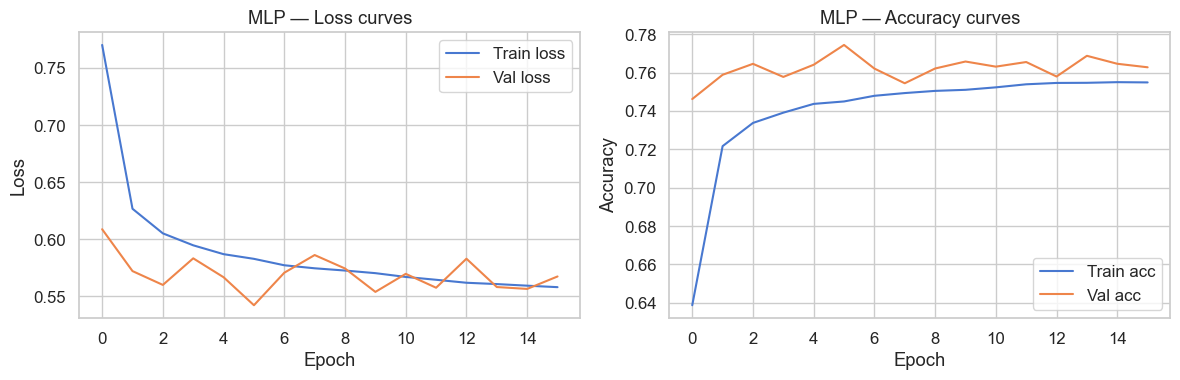

In [9]:
# ════════════════════════════════════════════════════════════
# CELL 9 · MODEL 4 — MLP NEURAL NETWORK (CLASSIFIER)
#
# Architecture mirrors Phase 2 MLP but the output layer uses
# softmax (4 units, one per class) instead of a single linear
# unit.  class_weight is passed to Keras .fit() so all 4
# classes are treated fairly during training.
# ════════════════════════════════════════════════════════════

print("\n" + "=" * 72)
print("  MODEL 4 — MLP NEURAL NETWORK  (classifier)")
print("=" * 72)

# Standardise with Phase 3 training data
scaler_mlp = StandardScaler()
X_tr_mlp   = scaler_mlp.fit_transform(X_tr_linear).astype("float32")
X_te_mlp   = scaler_mlp.transform(X_te_linear).astype("float32")
X_fit_mlp  = X_tr_mlp[:len(y_fit)]
X_val_mlp  = X_tr_mlp[len(y_fit):]

# One-hot encode targets for categorical crossentropy
y_fit_oh = keras.utils.to_categorical(y_fit, num_classes=N_CLASSES)
y_val_oh = keras.utils.to_categorical(y_val, num_classes=N_CLASSES)

mlp_clf = keras.Sequential([
    layers.Input(shape=(X_tr_mlp.shape[1],)),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.30),
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.25),
    layers.Dense(64,  activation="relu"),
    layers.Dropout(0.20),
    layers.Dense(N_CLASSES, activation="softmax"),
], name="mlp_classifier")

mlp_clf.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = "categorical_crossentropy",
    metrics   = ["accuracy"],
)
mlp_clf.summary()

cb_list = [
    K_CB.EarlyStopping(monitor="val_loss", patience=10,
                       restore_best_weights=True, verbose=1),
    K_CB.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                            patience=5, min_lr=1e-6, verbose=0),
]

t0 = time.time()
history = mlp_clf.fit(
    X_fit_mlp, y_fit_oh,
    validation_data = (X_val_mlp, y_val_oh),
    epochs          = 80,
    batch_size      = 2048,
    class_weight    = CLASS_WEIGHT_DICT,
    callbacks       = cb_list,
    verbose         = 1,
)
t1 = time.time()

proba_mlp = mlp_clf.predict(X_te_mlp, verbose=0)
pred_mlp  = proba_mlp.argmax(axis=1).astype("int32")
m_mlp = evaluate_clf("MLP Neural Network", y_test, pred_mlp, proba_mlp, t1 - t0)

mlp_clf.save(str(MODEL_DIR / "p3_mlp_classifier.keras"))
joblib.dump(scaler_mlp, MODEL_DIR / "p3_mlp_scaler.pkl")
print("  Saved -> outputs/models/p3_mlp_classifier.keras")

# Plot learning curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"],     label="Train loss")
axes[0].plot(history.history["val_loss"], label="Val loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("MLP — Loss curves"); axes[0].legend()
axes[1].plot(history.history["accuracy"],     label="Train acc")
axes[1].plot(history.history["val_accuracy"], label="Val acc")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("MLP — Accuracy curves"); axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "p3_00_mlp_training.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


In [10]:
# ════════════════════════════════════════════════════════════
# CELL 10 · RESULTS TABLE
# ════════════════════════════════════════════════════════════

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values("Macro F1", ascending=False).reset_index(drop=True)

print("\n" + "=" * 72)
print("  PHASE 3 — MODEL COMPARISON")
print("=" * 72)
display(results_df.set_index("Model"))

results_df.to_csv(OUTPUT_DIR / "phase3_results.csv", index=False)
print(f"Saved -> outputs/phase3_results.csv")

# Best model (excluding baseline)
non_baseline = results_df[results_df["Model"] != "Majority Baseline"]
best_row  = non_baseline.iloc[0]
best_name = best_row["Model"]
best_f1   = best_row["Macro F1"]
best_acc  = best_row["Accuracy (%)"]
best_pred = all_preds[best_name]
best_prob = all_probas[best_name]

baseline_f1  = results_df[results_df["Model"] == "Majority Baseline"]["Macro F1"].values[0]
f1_gain_pct  = (best_f1 - baseline_f1) / max(baseline_f1, 1e-9) * 100

print(f"\n✅  Best model : {best_name}")
print(f"   Accuracy   : {best_acc:.2f}%")
print(f"   Macro F1   : {best_f1:.4f}  (+{f1_gain_pct:.1f}% vs majority baseline)")
print(f"   AUC OvR    : {best_row['ROC-AUC (OvR)']:.4f}")



  PHASE 3 — MODEL COMPARISON


,Accuracy (%),Macro F1,Weighted F1,ROC-AUC (OvR),Log Loss,Delay Detect (%),F1 class-0,F1 class-1,F1 class-2,F1 class-3,Train time (s)
Model,,,,,,,,,,,
LightGBM,79.20,0.7793,0.7917,0.9382,0.5060,94.82,0.8194,0.7759,0.7299,0.7921,146.3
XGBoost,77.74,0.7548,0.7769,0.9322,0.5498,94.01,0.8106,0.7584,0.7143,0.7357,191.7
MLP Neural Network,75.86,0.7251,0.7574,0.9209,0.5937,93.63,0.7972,0.7327,0.7231,0.6473,50.8
Logistic Reg. (OvR),73.33,0.7059,0.7319,0.8853,0.8328,94.82,0.7620,0.7179,0.6752,0.6687,33.6
Logistic Reg. (Softmax),72.79,0.7055,0.7266,0.8975,0.7230,93.39,0.7677,0.6998,0.6674,0.6871,49.4
Majority Baseline,44.29,0.1535,0.2719,0.5000,8.8814,87.74,0.6139,0.0000,0.0000,0.0000,0.0


Saved -> outputs/phase3_results.csv

✅  Best model : LightGBM
   Accuracy   : 79.20%
   Macro F1   : 0.7793  (+407.7% vs majority baseline)
   AUC OvR    : 0.9382


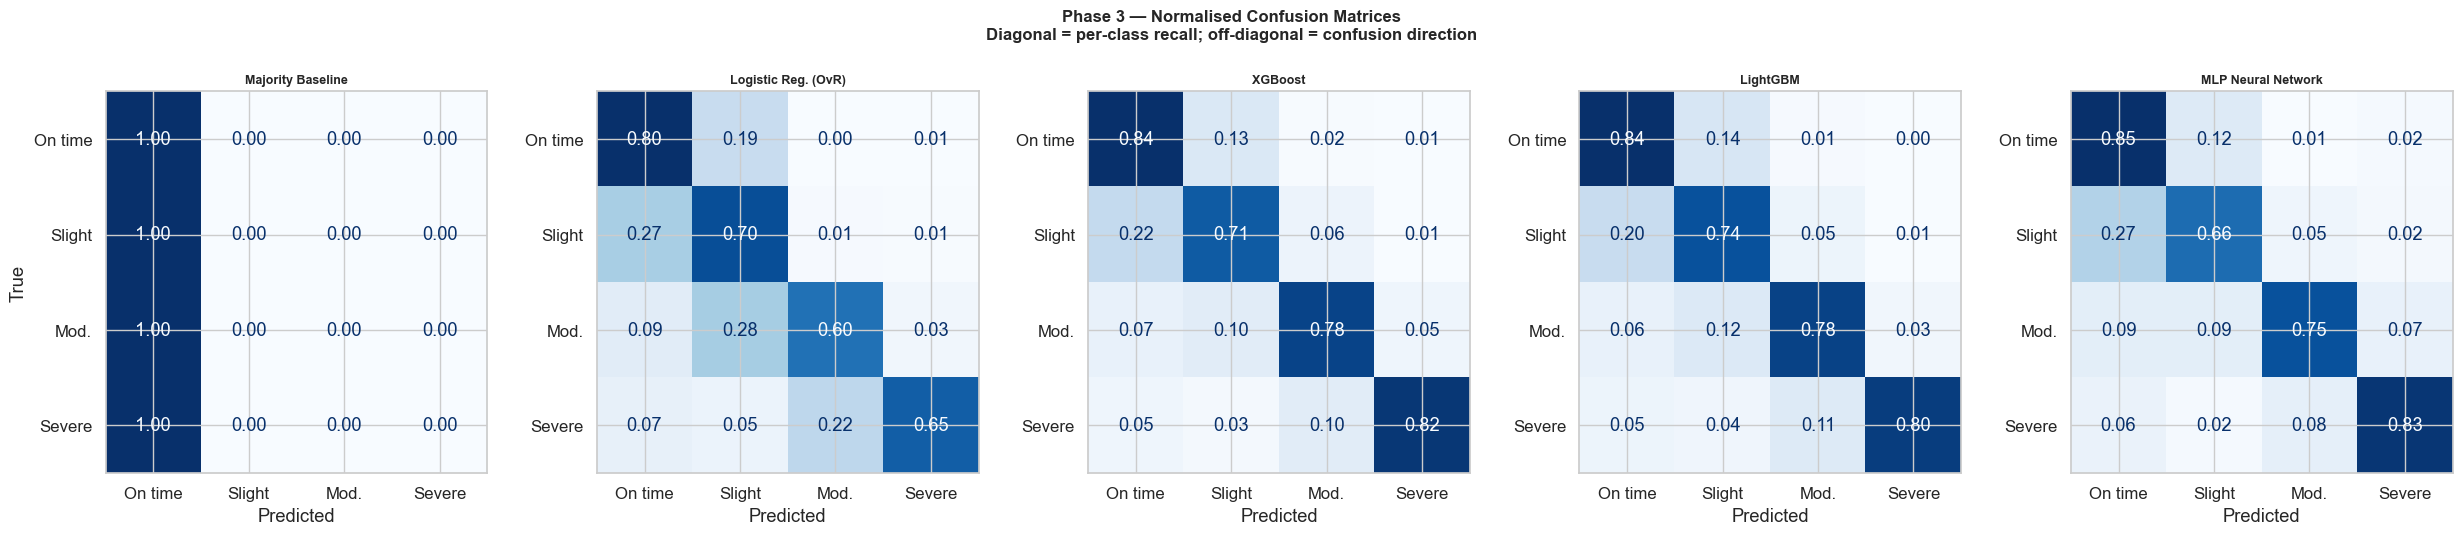

In [11]:
# ════════════════════════════════════════════════════════════
# CELL 11 · CHART 1 — NORMALISED CONFUSION MATRICES
# ════════════════════════════════════════════════════════════

labels_short = ["On time", "Slight", "Mod.", "Severe"]
model_plot_order = [
    "Majority Baseline",
    f"Logistic Reg. ({lr_variant})",
    "XGBoost",
    "LightGBM",
    "MLP Neural Network",
]
model_plot_order = [m for m in model_plot_order if m in all_preds]

n_models = len(model_plot_order)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))
if n_models == 1:
    axes = [axes]

for ax, mname in zip(axes, model_plot_order):
    cm = confusion_matrix(y_test, all_preds[mname], normalize="true")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=labels_short)
    disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format=".2f")
    ax.set_title(mname, fontsize=9, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True" if ax is axes[0] else "")

plt.suptitle("Phase 3 — Normalised Confusion Matrices\n"
             "Diagonal = per-class recall; off-diagonal = confusion direction",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "p3_01_confusion_matrices.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


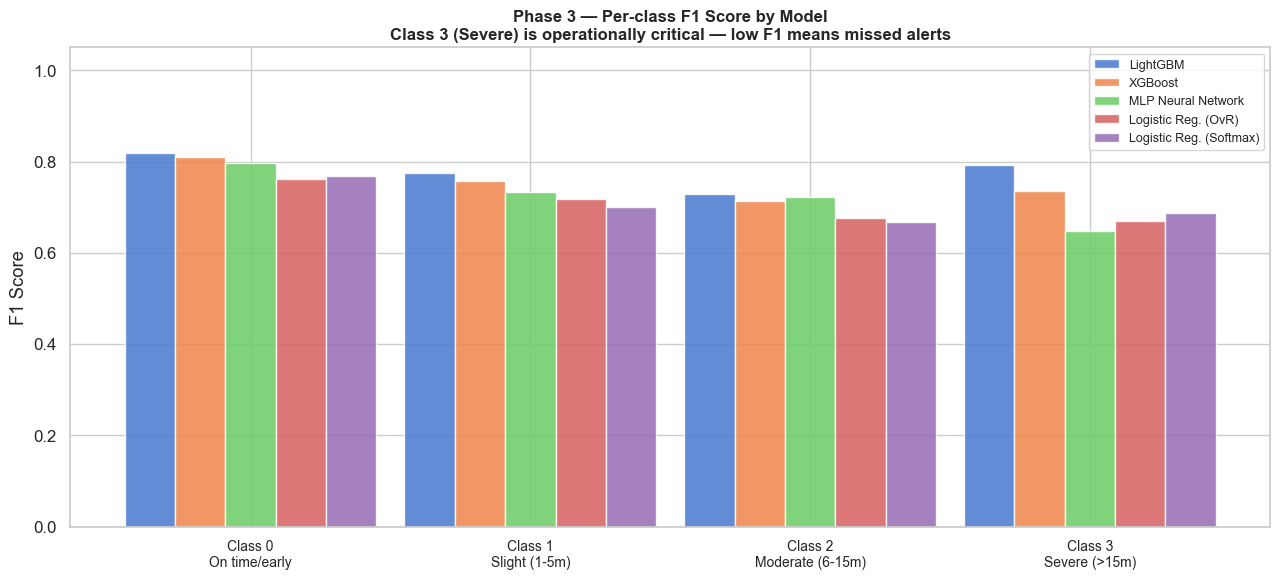

In [12]:
# ════════════════════════════════════════════════════════════
# CELL 12 · CHART 2 — PER-CLASS F1 SCORE BY MODEL
#
# The most operationally critical class is class 3 (Severe).
# A model that never predicts Severe is useless for operations
# even if its overall accuracy is high.
# ════════════════════════════════════════════════════════════

clf_cols  = ["F1 class-0", "F1 class-1", "F1 class-2", "F1 class-3"]
plot_mdls = [m for m in results_df["Model"].tolist() if m != "Majority Baseline"]

x       = np.arange(N_CLASSES)
width   = 0.18
offsets = np.linspace(-(len(plot_mdls)-1)*width/2,
                       (len(plot_mdls)-1)*width/2,
                       len(plot_mdls))

fig, ax = plt.subplots(figsize=(13, 6))
for i, mname in enumerate(plot_mdls):
    row = results_df[results_df["Model"] == mname].iloc[0]
    f1s = [row[c] for c in clf_cols]
    ax.bar(x + offsets[i], f1s, width,
           label=mname, color=PAL[i], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f"Class {k}\n{CLASS_LABELS[k]}" for k in range(N_CLASSES)],
                   fontsize=10)
ax.set_ylabel("F1 Score"); ax.set_ylim(0, 1.05)
ax.axhline(0, color="black", lw=0.5)
ax.set_title("Phase 3 — Per-class F1 Score by Model\n"
             "Class 3 (Severe) is operationally critical — low F1 means missed alerts",
             fontsize=12, fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "p3_02_perclass_f1.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()



Full classification report — LightGBM
                  precision    recall  f1-score   support

   On time/early     0.7953    0.8449    0.8194     78975
   Slight (1-5m)     0.8165    0.7391    0.7759     77474
Moderate (6-15m)     0.6833    0.7833    0.7299     15636
   Severe (>15m)     0.7836    0.8006    0.7921      6225

        accuracy                         0.7920    178310
       macro avg     0.7697    0.7920    0.7793    178310
    weighted avg     0.7943    0.7920    0.7917    178310



,Precision,Recall,F1 Score,Support
Class,,,,
On time/early,0.7953,0.8449,0.8194,78975
Slight (1-5m),0.8165,0.7391,0.7759,77474
Moderate (6-15m),0.6833,0.7833,0.7299,15636
Severe (>15m),0.7836,0.8006,0.7921,6225


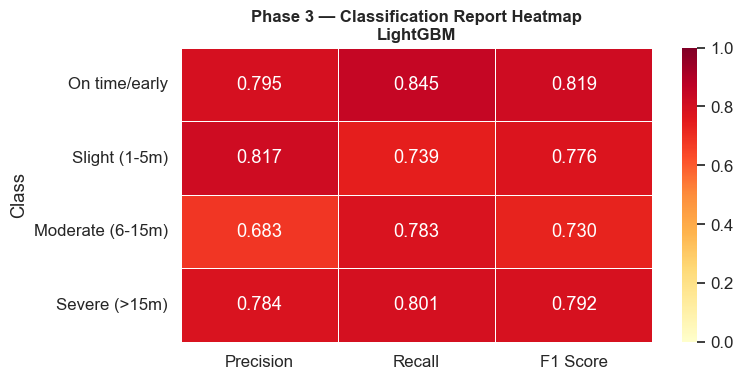

In [13]:
# ════════════════════════════════════════════════════════════
# CELL 13 · CHART 3 — CLASSIFICATION REPORT HEATMAP (best model)
# ════════════════════════════════════════════════════════════

print(f"\nFull classification report — {best_name}")
print("=" * 60)
print(classification_report(
    y_test, best_pred,
    target_names=[CLASS_LABELS[k] for k in range(N_CLASSES)],
    digits=4,
    zero_division=0,
))

# Build precision / recall / F1 per class
report_rows = []
for cls_idx in range(N_CLASSES):
    mask = y_test == cls_idx
    if mask.sum() == 0:
        continue
    tp = ((best_pred == cls_idx) & (y_test == cls_idx)).sum()
    fp = ((best_pred == cls_idx) & (y_test != cls_idx)).sum()
    fn = ((best_pred != cls_idx) & (y_test == cls_idx)).sum()
    prec   = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1_val = 2 * prec * recall / (prec + recall + 1e-9)
    report_rows.append({
        "Class"    : CLASS_LABELS[cls_idx],
        "Precision": round(prec, 4),
        "Recall"   : round(recall, 4),
        "F1 Score" : round(f1_val, 4),
        "Support"  : int(mask.sum()),
    })

report_df = pd.DataFrame(report_rows).set_index("Class")
display(report_df)

fig, ax = plt.subplots(figsize=(8, 4))
heat_data = report_df[["Precision", "Recall", "F1 Score"]].astype(float)
sns.heatmap(heat_data, annot=True, fmt=".3f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title(f"Phase 3 — Classification Report Heatmap\n{best_name}",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "p3_03_report_heatmap.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


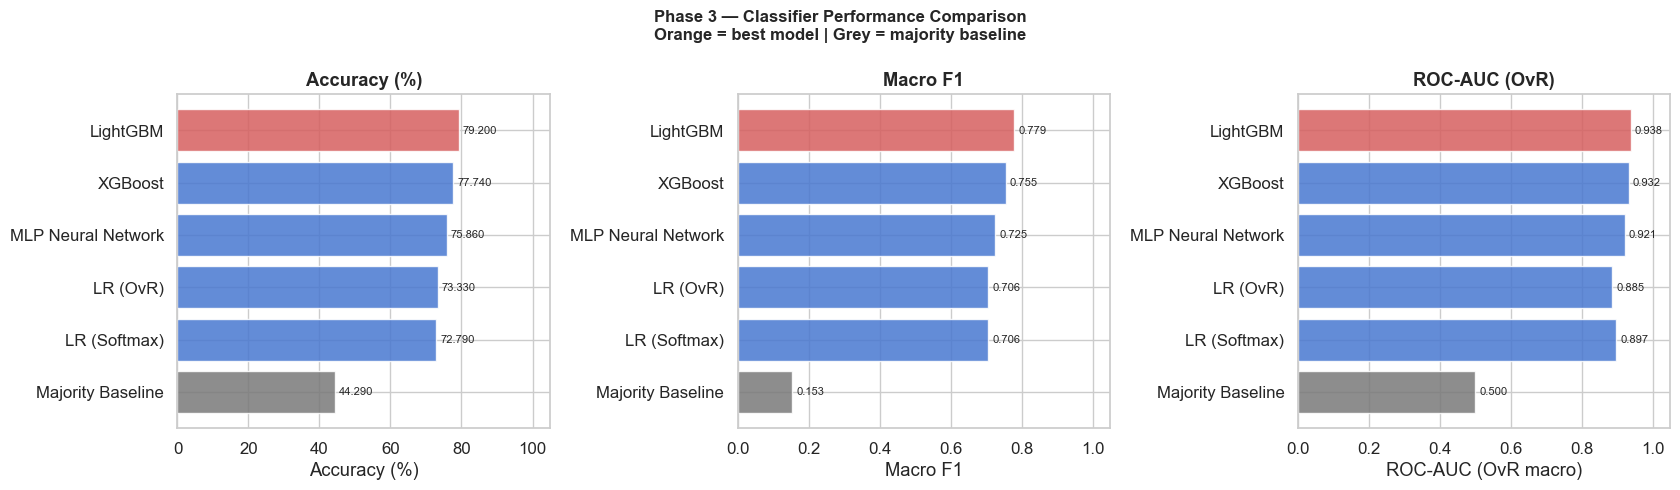

In [14]:
# ════════════════════════════════════════════════════════════
# CELL 14 · CHART 4 — MODEL COMPARISON (Acc + Macro F1 + AUC)
# ════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
metric_cols   = ["Accuracy (%)", "Macro F1", "ROC-AUC (OvR)"]
metric_ylims  = [(0, 105), (0, 1.05), (0, 1.05)]
metric_labels = ["Accuracy (%)", "Macro F1", "ROC-AUC (OvR macro)"]

for ax, col, ylim, ylabel in zip(axes, metric_cols, metric_ylims, metric_labels):
    vals  = results_df[col].values
    names = [n.replace("Logistic Reg. ", "LR ") for n in results_df["Model"]]
    colors = []
    for n in names:
        if best_name.replace("Logistic Reg. ", "LR ") in n:
            colors.append(PAL[3])
        elif "Baseline" in n:
            colors.append(PAL[7])
        else:
            colors.append(PAL[0])
    bars = ax.barh(names, vals, color=colors, alpha=0.85)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
    ax.set_xlim(*ylim)
    ax.set_xlabel(ylabel)
    ax.invert_yaxis()
    ax.set_title(col, fontweight="bold")

plt.suptitle("Phase 3 — Classifier Performance Comparison\n"
             "Orange = best model | Grey = majority baseline",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "p3_04_model_comparison.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


Top 5 by sklearn feature_importances_ (sanity check):
              feature  importance
prev_stop_was_delayed    0.395335
      prev_stop_delay    0.235012
       delay_rolling3    0.064071
        traintype_p75    0.029945
        is_first_stop    0.021371

Top 5 by gain from get_score (should match):
              feature  importance
prev_stop_was_delayed 1435.815063
      prev_stop_delay  853.537231
       delay_rolling3  232.698196
        traintype_p75  108.757851
        is_first_stop   77.615662


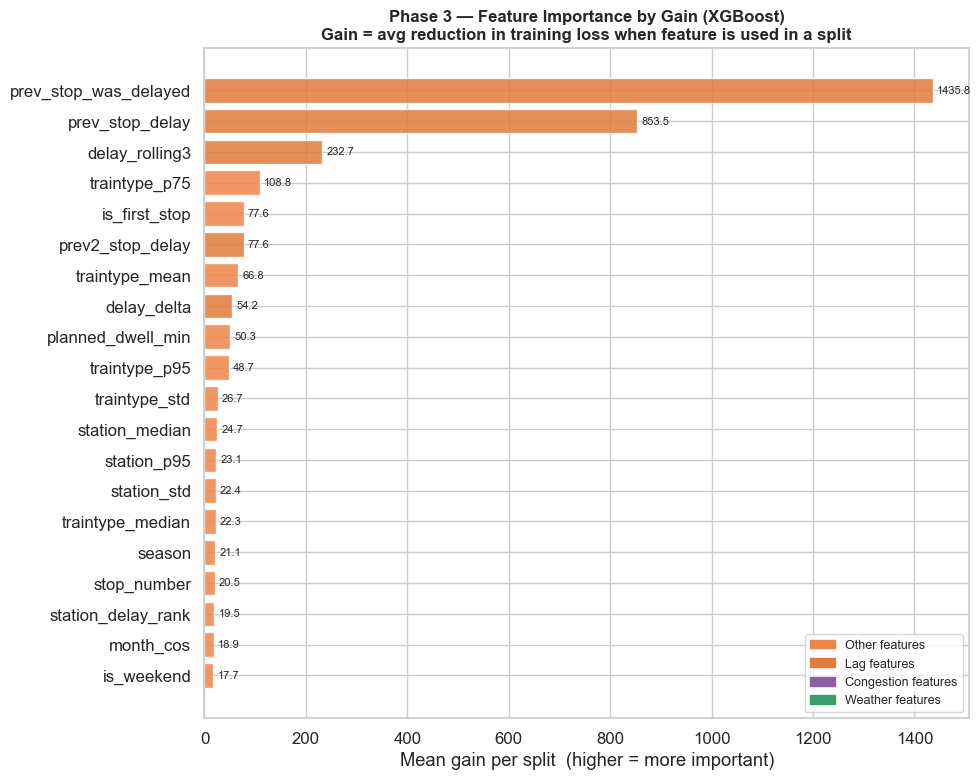

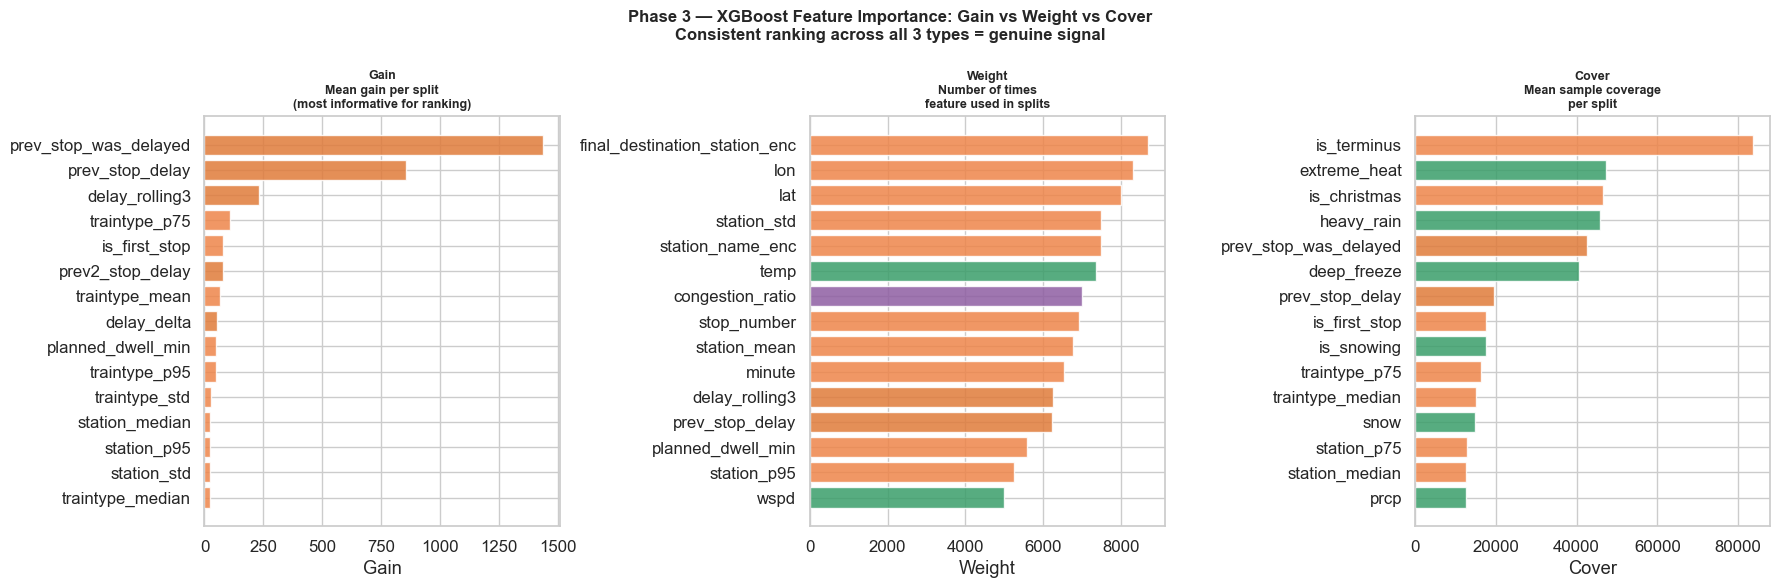


Feature importances saved -> outputs/phase3_shap_importance.csv

  Top 10 features by gain:
              feature  importance
prev_stop_was_delayed 1435.815063
      prev_stop_delay  853.537231
       delay_rolling3  232.698196
        traintype_p75  108.757851
        is_first_stop   77.615662
     prev2_stop_delay   77.556801
       traintype_mean   66.845284
          delay_delta   54.165615
    planned_dwell_min   50.306881
        traintype_p95   48.654831


In [19]:
# ════════════════════════════════════════════════════════════
# CELL 15 · CHART 5 — FEATURE IMPORTANCE (XGBoost)  [FIXED v4]
#
# Root cause of zeros: get_score() keys are "f0","f1",... when
# the model was trained on a numpy array, not a named DataFrame.
# Fix: use xgb_clf.feature_importances_ which is already
# correctly aligned to FEATURES_TREE by index position.
# ════════════════════════════════════════════════════════════

# ── Build importance DataFrames from feature_importances_ ────
# feature_importances_ is the mean gain (split-weighted) across
# all trees, already aligned to FEATURES_TREE by position.
# We also extract weight and cover via get_score with "f{i}" keys.

booster = xgb_clf.get_booster()

# Map "f0","f1",... back to actual feature names
fmap = {f"f{i}": name for i, name in enumerate(FEATURES_TREE)}

imp_dfs = {}
for imp_type in ["gain", "weight", "cover"]:
    scores_raw = booster.get_score(importance_type=imp_type)
    # Translate "f0" -> actual feature name, fill missing with 0
    imp_vec = []
    for i, feat in enumerate(FEATURES_TREE):
        key = f"f{i}"
        imp_vec.append(scores_raw.get(key, 0.0))
    imp_dfs[imp_type] = pd.DataFrame({
        "feature"   : FEATURES_TREE,
        "importance": imp_vec,
    }).sort_values("importance", ascending=False)

# Use 'gain' as primary (same as feature_importances_ but explicit)
shap_imp = imp_dfs["gain"].copy()

# Quick sanity check — should match xgb_clf.feature_importances_
sklearn_imp = pd.DataFrame({
    "feature"   : FEATURES_TREE,
    "importance": xgb_clf.feature_importances_,
}).sort_values("importance", ascending=False)
print("Top 5 by sklearn feature_importances_ (sanity check):")
print(sklearn_imp.head(5).to_string(index=False))
print("\nTop 5 by gain from get_score (should match):")
print(shap_imp.head(5).to_string(index=False))

# ── Plot 1: top 20 features by gain ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
top_n          = 20
top_feats_plot = shap_imp["feature"].iloc[:top_n].tolist()
top_vals_plot  = shap_imp["importance"].iloc[:top_n].tolist()

bar_colors = []
for f in top_feats_plot:
    if f in LAG_FEATURES:           bar_colors.append("#e07b3a")
    elif f in CONGESTION_FEATURES:  bar_colors.append("#8e5ea2")
    elif f in WEATHER_FEATURES:     bar_colors.append("#3a9e6a")
    else:                           bar_colors.append(PAL[1])

bars = ax.barh(top_feats_plot[::-1], top_vals_plot[::-1],
               color=bar_colors[::-1], alpha=0.85)
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=8)
ax.set_xlabel("Mean gain per split  (higher = more important)")
ax.set_title("Phase 3 — Feature Importance by Gain (XGBoost)\n"
             "Gain = avg reduction in training loss when feature is used in a split",
             fontsize=12, fontweight="bold")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=PAL[1],    label="Other features"),
    Patch(color="#e07b3a", label="Lag features"),
    Patch(color="#8e5ea2", label="Congestion features"),
    Patch(color="#3a9e6a", label="Weather features"),
], fontsize=9, loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "p3_05_shap_global.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

# ── Plot 2: all 3 importance types side by side ───────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
descriptions = {
    "gain"  : "Mean gain per split\n(most informative for ranking)",
    "weight": "Number of times\nfeature used in splits",
    "cover" : "Mean sample coverage\nper split",
}
for ax, imp_type in zip(axes, ["gain", "weight", "cover"]):
    df_i = imp_dfs[imp_type]
    top  = df_i.iloc[:15]
    colors_i = []
    for f in top["feature"]:
        if f in LAG_FEATURES:           colors_i.append("#e07b3a")
        elif f in CONGESTION_FEATURES:  colors_i.append("#8e5ea2")
        elif f in WEATHER_FEATURES:     colors_i.append("#3a9e6a")
        else:                           colors_i.append(PAL[1])
    ax.barh(top["feature"][::-1], top["importance"][::-1],
            color=colors_i[::-1], alpha=0.85)
    ax.set_title(f"{imp_type.capitalize()}\n{descriptions[imp_type]}",
                 fontweight="bold", fontsize=9)
    ax.set_xlabel(imp_type.capitalize())

plt.suptitle("Phase 3 — XGBoost Feature Importance: Gain vs Weight vs Cover\n"
             "Consistent ranking across all 3 types = genuine signal",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "p3_05b_importance_types.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

# ── Save & print ─────────────────────────────────────────────
shap_imp.to_csv(OUTPUT_DIR / "phase3_shap_importance.csv", index=False)
print("\nFeature importances saved -> outputs/phase3_shap_importance.csv")
print(f"\n  Top 10 features by gain:")
print(shap_imp.head(10).to_string(index=False))

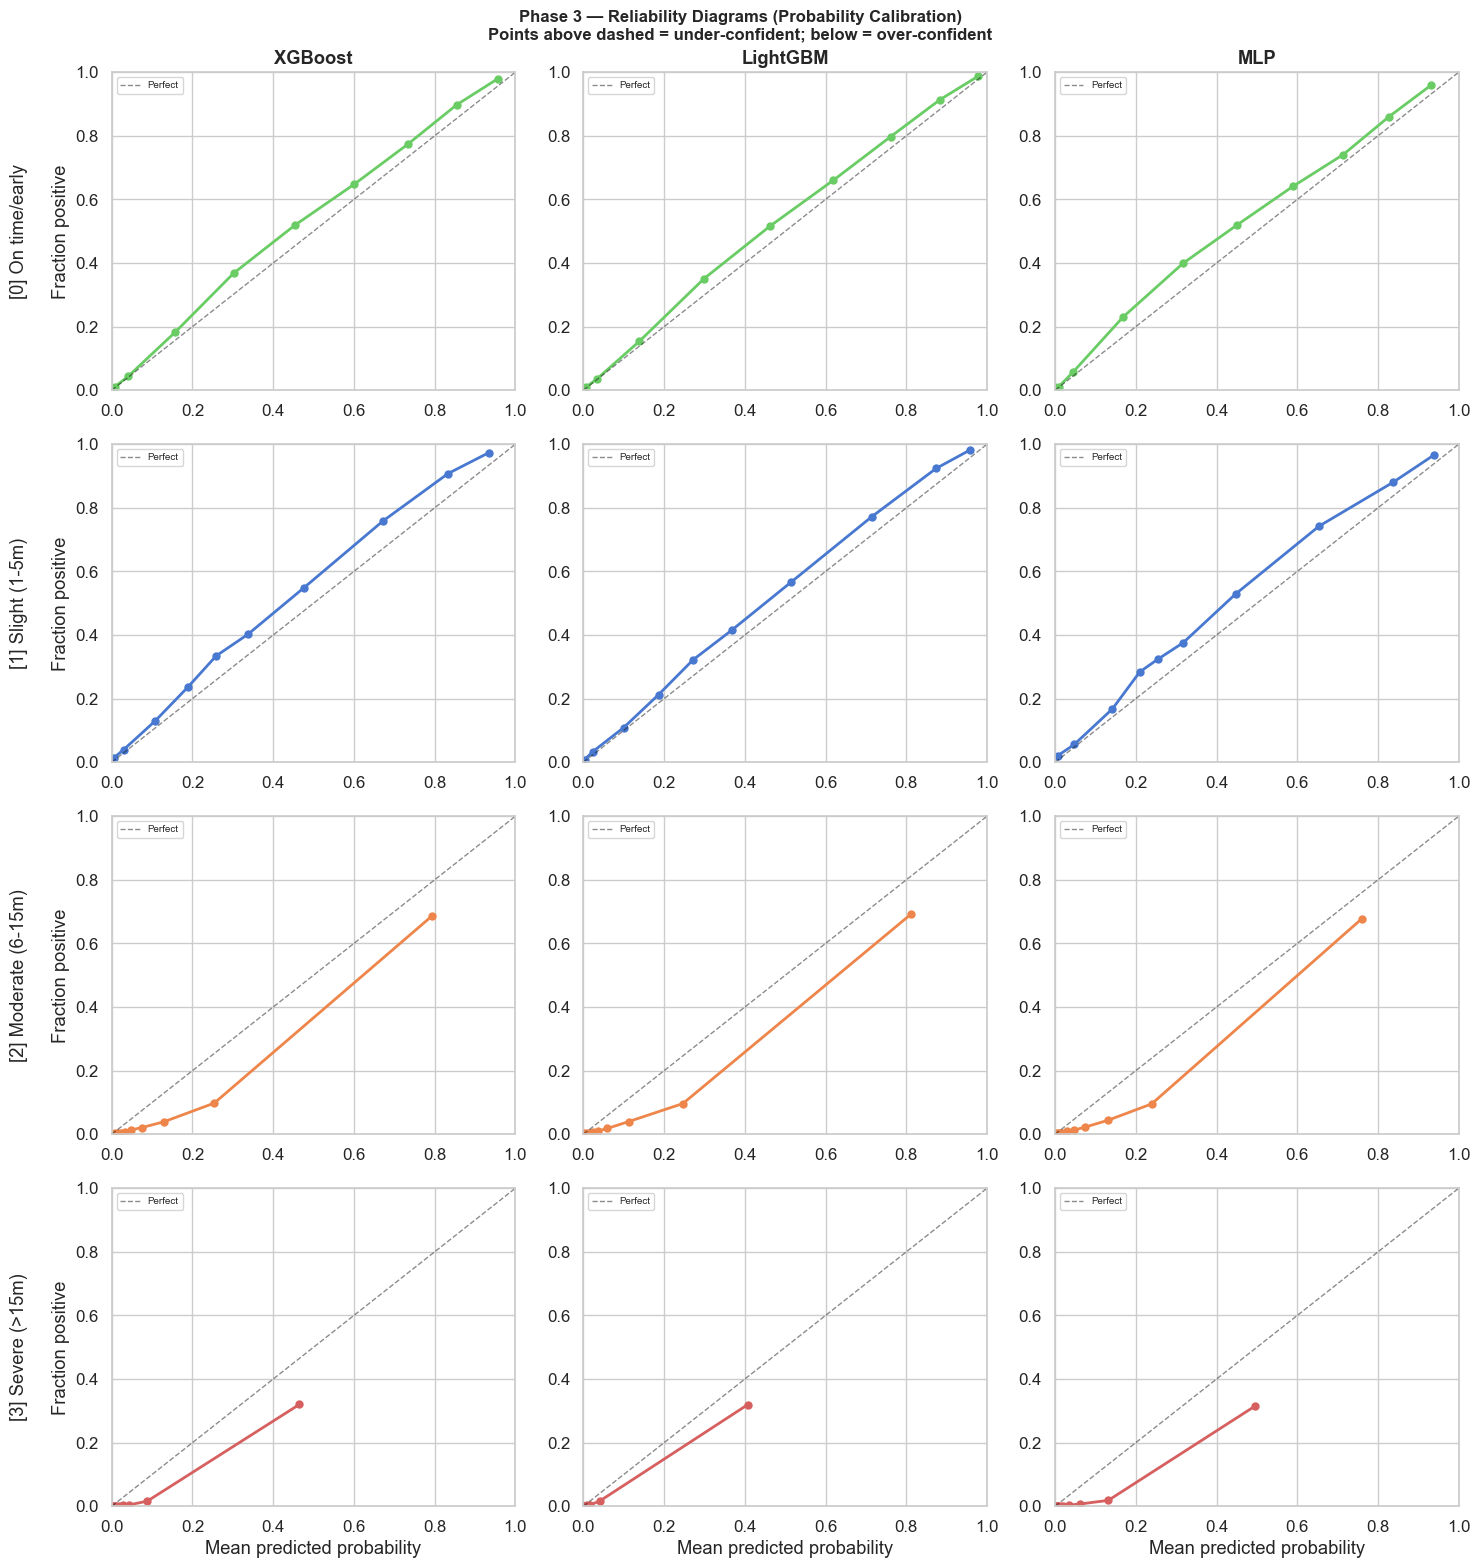

In [20]:
# ════════════════════════════════════════════════════════════
# CELL 16 · CHART 6 — PROBABILITY CALIBRATION CURVES
#
# A well-calibrated model: when it says P(severe) = 0.7,
# about 70% of those cases should actually be severe.
# Under-calibration (overconfident) and over-calibration
# (uncertain) are both problematic for operational use.
# ════════════════════════════════════════════════════════════

top_models_cal = {
    "XGBoost" : proba_xgb,
    "LightGBM": proba_lgbm,
    "MLP"     : proba_mlp,
}

fig, axes = plt.subplots(N_CLASSES, 3, figsize=(15, 4 * N_CLASSES))

for col_i, (mname, proba) in enumerate(top_models_cal.items()):
    for cls_idx in range(N_CLASSES):
        ax       = axes[cls_idx, col_i]
        true_bin = (y_test == cls_idx).astype(int)
        prob_cls = proba[:, cls_idx]

        try:
            frac_pos, mean_pred = calibration_curve(
                true_bin, prob_cls, n_bins=10, strategy="quantile"
            )
            ax.plot(mean_pred, frac_pos, marker="o", ms=5,
                    color=CLASS_COLORS[cls_idx], lw=2)
        except Exception:
            ax.text(0.5, 0.5, "Insufficient\ndata",
                    ha="center", va="center", transform=ax.transAxes, fontsize=9)

        ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Perfect")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        if col_i == 0:
            ax.set_ylabel(f"[{cls_idx}] {CLASS_LABELS[cls_idx]}\n\nFraction positive")
        if cls_idx == 0:
            ax.set_title(mname, fontweight="bold")
        if cls_idx == N_CLASSES - 1:
            ax.set_xlabel("Mean predicted probability")
        ax.legend(fontsize=7)

plt.suptitle("Phase 3 — Reliability Diagrams (Probability Calibration)\n"
             "Points above dashed = under-confident; below = over-confident",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "p3_06_calibration_curves.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


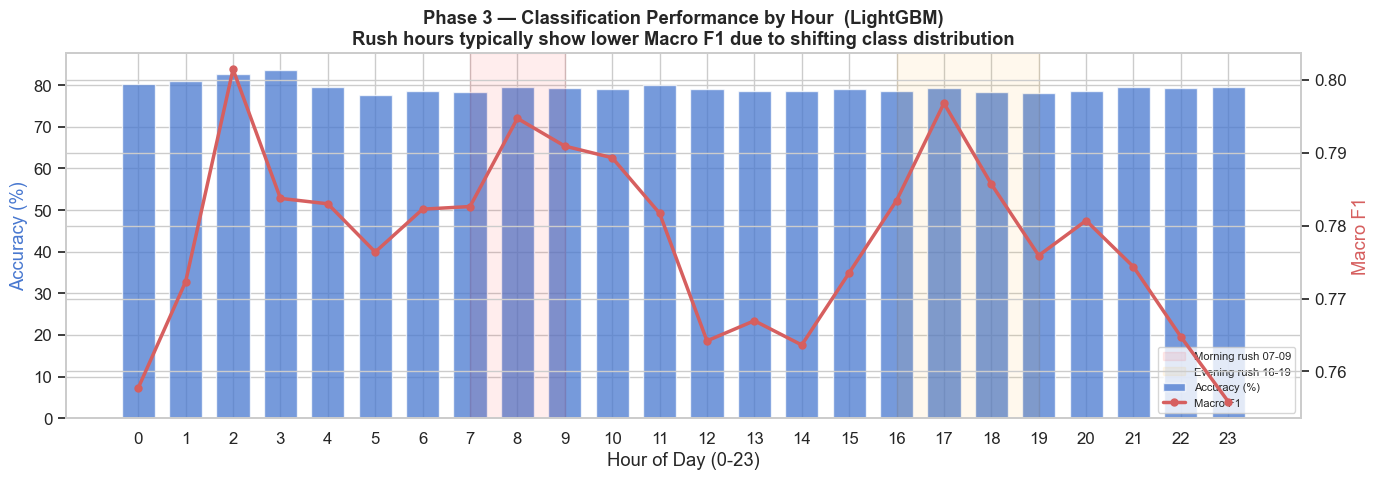

In [21]:
# ════════════════════════════════════════════════════════════
# CELL 17 · CHART 7 — ACCURACY & MACRO F1 BY HOUR OF DAY
# ════════════════════════════════════════════════════════════

test_hrs = df_test["hour"].values
hr_rows  = []
for h in range(24):
    mask = test_hrs == h
    if mask.sum() < 100:
        continue
    acc_h  = accuracy_score(y_test[mask], best_pred[mask])
    f1_h   = f1_score(y_test[mask], best_pred[mask], average="macro", zero_division=0)
    hr_rows.append({"hour": h, "Accuracy (%)": acc_h * 100, "Macro F1": f1_h})

hr_df = pd.DataFrame(hr_rows)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(hr_df["hour"], hr_df["Accuracy (%)"], color=PAL[0], alpha=0.75,
        width=0.7, label="Accuracy (%)")
ax2.plot(hr_df["hour"], hr_df["Macro F1"], color=PAL[3],
         lw=2.5, marker="o", ms=5, label="Macro F1")

ax1.axvspan(7,  9,  alpha=0.07, color="red",    label="Morning rush 07-09")
ax1.axvspan(16, 19, alpha=0.07, color="orange", label="Evening rush 16-19")
ax1.set_xticks(range(24))
ax1.set_xlabel("Hour of Day (0-23)")
ax1.set_ylabel("Accuracy (%)", color=PAL[0])
ax2.set_ylabel("Macro F1",     color=PAL[3])
ax1.set_title(f"Phase 3 — Classification Performance by Hour  ({best_name})\n"
              "Rush hours typically show lower Macro F1 due to shifting class distribution",
              fontweight="bold")

lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "p3_07_performance_by_hour.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


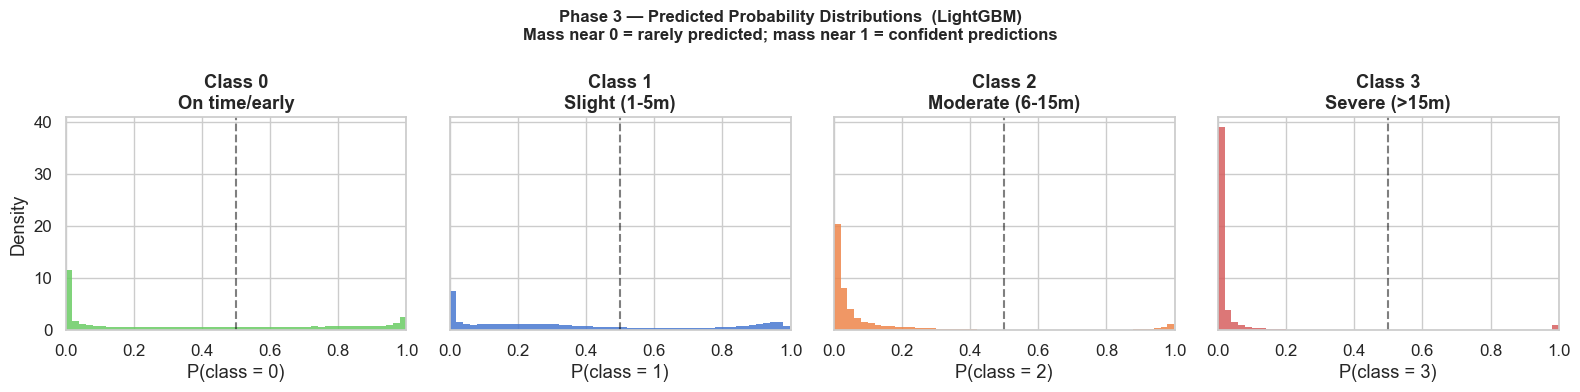

In [22]:
# ════════════════════════════════════════════════════════════
# CELL 18 · CHART 8 — PREDICTED PROBABILITY DISTRIBUTIONS
#
# Peaked at 0 and 1: decisive model.
# Concentrated around 0.5: poorly calibrated / uncertain model.
# ════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, N_CLASSES, figsize=(16, 4), sharey=True)

for cls_idx, ax in enumerate(axes):
    probs = best_prob[:, cls_idx]
    ax.hist(probs, bins=50, color=CLASS_COLORS[cls_idx],
            alpha=0.85, edgecolor="none", density=True)
    ax.axvline(0.5, color="black", lw=1.5, ls="--", alpha=0.5)
    ax.set_xlabel(f"P(class = {cls_idx})")
    ax.set_title(f"Class {cls_idx}\n{CLASS_LABELS[cls_idx]}", fontweight="bold")
    ax.set_xlim(0, 1)

axes[0].set_ylabel("Density")
plt.suptitle(f"Phase 3 — Predicted Probability Distributions  ({best_name})\n"
             "Mass near 0 = rarely predicted; mass near 1 = confident predictions",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "p3_08_probability_distributions.png",
            dpi=FIG_DPI, bbox_inches="tight")
plt.show()


Regression Phase 2 (discretised) accuracy : 53.10%  (continuous output binned into classes)
Classification Phase 3 accuracy           : 79.20%
Phase 2 and Phase 3 agree with each other : 51.67%


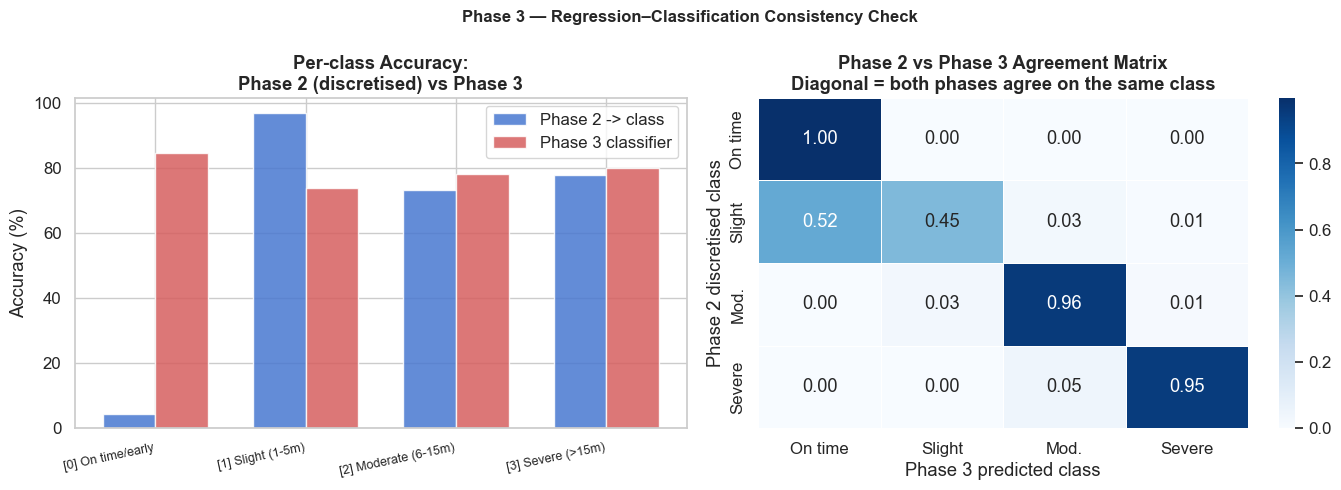

In [23]:
# ════════════════════════════════════════════════════════════
# CELL 19 · CHART 9 — REGRESSION–CLASSIFICATION CONSISTENCY
#
# Internal consistency check: does Phase 3 classification
# agree with Phase 2 regression discretised to the same classes?
# This is NOT a new evaluation — it checks that the two phases
# produce coherent outputs on the same test set.
# ════════════════════════════════════════════════════════════

pred_out_p2 = pd.read_parquet(OUTPUT_DIR / "phase2_predictions.parquet")

def delay_to_class(d):
    if d <= 0:    return 0
    elif d <= 5:  return 1
    elif d <= 15: return 2
    else:          return 3

p2_class = pred_out_p2["predicted_delay"].apply(delay_to_class).values
p3_class = best_pred[:len(p2_class)]
true_cls  = y_test[:len(p2_class)]

agree_p2  = (p2_class == true_cls).mean() * 100
agree_p3  = (p3_class == true_cls).mean() * 100
agree_p2p3 = (p2_class == p3_class).mean() * 100

print("Regression Phase 2 (discretised) accuracy : "
      f"{agree_p2:.2f}%  (continuous output binned into classes)")
print(f"Classification Phase 3 accuracy           : {agree_p3:.2f}%")
print(f"Phase 2 and Phase 3 agree with each other : {agree_p2p3:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

classes_agr = []
for k in range(N_CLASSES):
    mask = true_cls == k
    if mask.sum() < 20:
        continue
    classes_agr.append({
        "class"        : f"[{k}] {CLASS_LABELS[k]}",
        "Phase2->class": (p2_class[mask] == true_cls[mask]).mean() * 100,
        "Phase3 clf"   : (p3_class[mask] == true_cls[mask]).mean() * 100,
    })
agr_df = pd.DataFrame(classes_agr)

x, w = np.arange(len(agr_df)), 0.35
axes[0].bar(x - w/2, agr_df["Phase2->class"], w,
            label="Phase 2 -> class", color=PAL[0], alpha=0.85)
axes[0].bar(x + w/2, agr_df["Phase3 clf"],   w,
            label="Phase 3 classifier", color=PAL[3], alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(agr_df["class"], rotation=12, ha="right", fontsize=9)
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Per-class Accuracy:\nPhase 2 (discretised) vs Phase 3",
                   fontweight="bold")
axes[0].legend()

labels_short = ["On time", "Slight", "Mod.", "Severe"]
cm_agr = confusion_matrix(p2_class, p3_class, normalize="true")
sns.heatmap(cm_agr, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=labels_short, yticklabels=labels_short,
            ax=axes[1], linewidths=0.5)
axes[1].set_xlabel("Phase 3 predicted class")
axes[1].set_ylabel("Phase 2 discretised class")
axes[1].set_title("Phase 2 vs Phase 3 Agreement Matrix\n"
                  "Diagonal = both phases agree on the same class",
                  fontweight="bold")

plt.suptitle("Phase 3 — Regression–Classification Consistency Check",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "p3_09_regression_clf_agreement.png",
            dpi=FIG_DPI, bbox_inches="tight")
plt.show()


In [24]:
# ════════════════════════════════════════════════════════════
# CELL 20 · SAVE BEST MODEL + PREDICTIONS + CONFIG
# ════════════════════════════════════════════════════════════

model_map = {
    "Majority Baseline"       : None,
    "Logistic Reg. (OvR)"    : pipe_lr if lr_variant == "OvR" else None,
    "Logistic Reg. (Softmax)": pipe_lr if lr_variant == "Softmax" else None,
    "XGBoost"                 : xgb_clf,
    "LightGBM"                : lgbm_clf,
    "MLP Neural Network"      : mlp_clf,
}

best_obj = model_map.get(best_name)
if best_name == "MLP Neural Network":
    mlp_clf.save(str(MODEL_DIR / "p3_best_model.keras"))
    joblib.dump(scaler_mlp, MODEL_DIR / "p3_best_scaler.pkl")
elif best_obj is not None:
    joblib.dump(best_obj, MODEL_DIR / "p3_best_model.pkl")
print(f"Best model saved -> outputs/models/p3_best_model.*")

# Predictions with probabilities
keep_cols = ["departure_planned_time", "station_name",
             "train_type", "delay_class", "delay_in_min"]
for extra in ["prev_stop_delay", "weather_disruption",
              "trains_this_hour", "train_line_ride_id", "hour"]:
    if extra in df_test.columns:
        keep_cols.append(extra)

pred_df = df_test[keep_cols].copy()
pred_df["predicted_class"] = best_pred
pred_df["true_class"]      = y_test
pred_df["correct"]         = (best_pred == y_test).astype("int8")
for k in range(N_CLASSES):
    pred_df[f"prob_class_{k}"] = best_prob[:, k]
pred_df["predicted_label"] = [CLASS_LABELS[c] for c in best_pred]
pred_df.to_parquet(OUTPUT_DIR / "phase3_predictions.parquet", index=False)
print("Predictions saved -> outputs/phase3_predictions.parquet")

phase3_cfg = {
    "best_model_name"    : best_name,
    "best_accuracy"      : float(best_row["Accuracy (%)"]),
    "best_macro_f1"      : float(best_row["Macro F1"]),
    "best_weighted_f1"   : float(best_row["Weighted F1"]),
    "best_roc_auc"       : float(best_row["ROC-AUC (OvR)"]),
    "n_classes"          : N_CLASSES,
    "class_labels"       : {str(k): v for k, v in CLASS_LABELS.items()},
    "FEATURES_TREE"      : FEATURES_TREE,
    "FEATURES_LINEAR"    : FEATURES_LINEAR,
    "WEATHER_FEATURES"   : WEATHER_FEATURES,
    "LAG_FEATURES"       : LAG_FEATURES,
    "CONGESTION_FEATURES": CONGESTION_FEATURES,
    "TARGET_CLF"         : TARGET_CLF,
    "TARGET_REG"         : TARGET_REG,
    "LEAKAGE_COLS"       : LEAKAGE_COLS,
    "all_model_results"  : all_results,
    "split_strategy"     : "ride_based_GroupShuffleSplit",
    "early_stopping_val" : "train_internal_10pct",
    "class_weights"      : {str(k): float(v) for k, v in CLASS_WEIGHT_DICT.items()},
}
with open(OUTPUT_DIR / "phase3_config.json", "w") as f:
    json.dump(phase3_cfg, f, indent=2)
print("Phase 3 config   -> outputs/phase3_config.json")


Best model saved -> outputs/models/p3_best_model.*
Predictions saved -> outputs/phase3_predictions.parquet
Phase 3 config   -> outputs/phase3_config.json


In [25]:
# ════════════════════════════════════════════════════════════
# CELL 21 · FINAL SUMMARY
# ════════════════════════════════════════════════════════════

best_f1_s3  = round(float(best_row["Macro F1"]), 4)
best_acc_s3 = round(float(best_row["Accuracy (%)"]), 2)
best_auc_s3 = round(float(best_row["ROC-AUC (OvR)"]), 4)
best_wf1_s3 = round(float(best_row["Weighted F1"]), 4)
best_f1_3   = round(float(best_row["F1 class-3"]), 4)

sep = "=" * 70
print(sep)
print(f"  PHASE 3 COMPLETE -- CLASSIFICATION  (honest evaluation)")
print(sep)
print(f"  Models trained         : 5  (Baseline + LogReg + XGB + LGBM + MLP)")
print(f"  Best model             : {best_name}")
print(f"  Accuracy               : {best_acc_s3:.2f}%")
print(f"  Macro F1               : {best_f1_s3:.4f}")
print(f"  Weighted F1            : {best_wf1_s3:.4f}")
print(f"  ROC-AUC (OvR macro)    : {best_auc_s3:.4f}")
print(f"  F1 Severe (class-3)    : {best_f1_3:.4f}  <- operationally critical")
print(sep)
print("  Delay classes:")
print("    [0] On time/early    <= 0 min")
print("    [1] Slight            1-5 min")
print('    [2] Moderate          6-15 min  (DB official "delayed" threshold)')
print("    [3] Severe            >15 min   (triggers passenger compensation)")
print(sep)
print("  EVALUATION INTEGRITY:")
print("    Split     : ride-based GroupShuffleSplit (zero ride overlap)")
print("    ES valida.: train-internal 10% slice (NOT test set)")
print('    Imbalance : class_weight="balanced" on all models')
print("    Leakage   : delay_in_min, delay_class excluded from features OK")
print(sep)
print("  Outputs:")
print("    outputs/phase3_results.csv")
print("    outputs/phase3_predictions.parquet")
print("    outputs/phase3_config.json")
print("    outputs/phase3_shap_importance.csv")
print("    outputs/models/p3_best_model.*")
print("    outputs/figures/p3_00 to p3_09  (10 charts)")
print(sep)
print("  Next: Phase 4 -> Deep Learning & Geospatial")
print("    LSTM delay propagation, Autoencoder anomaly detection,")
print("    K-Means geo clustering, optional Transformer attention")
print(sep)


  PHASE 3 COMPLETE -- CLASSIFICATION  (honest evaluation)
  Models trained         : 5  (Baseline + LogReg + XGB + LGBM + MLP)
  Best model             : LightGBM
  Accuracy               : 79.20%
  Macro F1               : 0.7793
  Weighted F1            : 0.7917
  ROC-AUC (OvR macro)    : 0.9382
  F1 Severe (class-3)    : 0.7921  <- operationally critical
  Delay classes:
    [0] On time/early    <= 0 min
    [1] Slight            1-5 min
    [2] Moderate          6-15 min  (DB official "delayed" threshold)
    [3] Severe            >15 min   (triggers passenger compensation)
  EVALUATION INTEGRITY:
    Split     : ride-based GroupShuffleSplit (zero ride overlap)
    ES valida.: train-internal 10% slice (NOT test set)
    Imbalance : class_weight="balanced" on all models
    Leakage   : delay_in_min, delay_class excluded from features OK
  Outputs:
    outputs/phase3_results.csv
    outputs/phase3_predictions.parquet
    outputs/phase3_config.json
    outputs/phase3_shap_importance.c